In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import glob

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)

In [2]:
# 30-39
rcm_past = "../plotting_data/orig_RCM_30-39/id011/*.npy"
emul_past = "../plotting_data/corrdiff/30-39/per_file_id011/*.npy"
gcm_past = "../plotting_data/GCM/*.npy"
# 90-99
rcm_future = "../plotting_data/orig_RCM/90-99/*.npy"
gcm_future = "../plotting_data/GCM/90-99/*.npy"
emul_future = "../plotting_data/corrdiff/per_file/*.npy"
emul_files = sorted(glob.glob(emul_past))
orig_files = sorted(glob.glob(rcm_past))
gcm_files = sorted(glob.glob(gcm_past))

emul_files_2 = sorted(glob.glob(emul_future))
orig_files_2 = sorted(glob.glob(rcm_future))
gcm_files_2 = sorted(glob.glob(gcm_future))

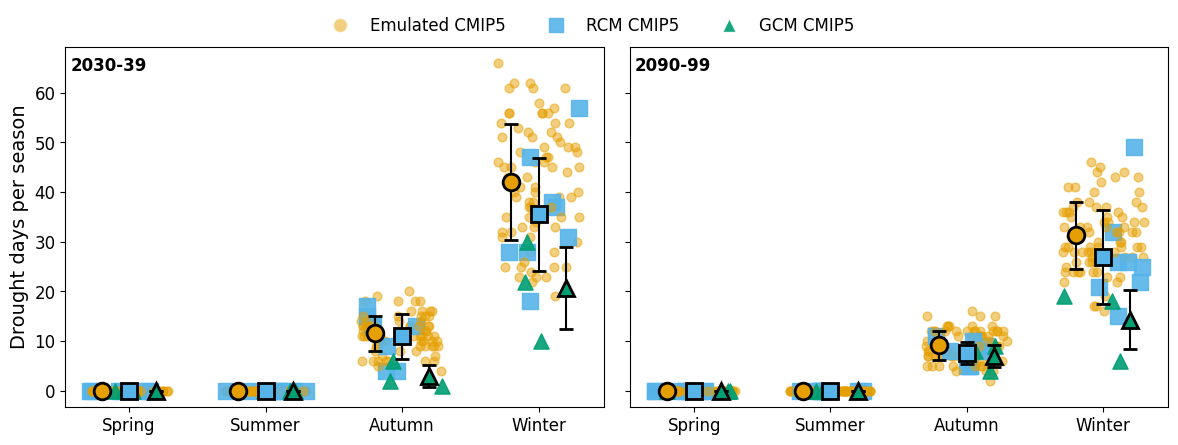

In [ ]:
seed = 42
rng = np.random.default_rng(seed)
emul_color = "#E69F00"
orig_color = "#56B4E9"
gcm_color = "#009E73"


def plot_co_occurring(ax, emul_files, orig_files, gcm_files):

    # Containers to accumulate data for mean/std computation
    all_emul = []
    all_orig = []
    all_gcm = []

    new_order = [1, 2, 0, 3]

    # --- Emulated and Original ---
    for emul_file, orig_file in zip(emul_files, orig_files):
        # --- Emulated ---
        season_counts_np = np.load(emul_file, allow_pickle=True)
        if isinstance(season_counts_np, dict):
            season_counts_np = list(season_counts_np.values())[0]

        ensembles, n_seasons = season_counts_np.shape

        # Reorder columns
        season_counts_np = season_counts_np[:, new_order]
        all_emul.append(season_counts_np)

        for e in range(ensembles):
            x = np.arange(n_seasons) + np.random.uniform(-0.3, 0.3, size=n_seasons)
            y = season_counts_np[e, :]
            ax.scatter(x, y, color=emul_color, alpha=0.5, s=40)

        # --- Original ---
        season_counts_np = np.load(orig_file, allow_pickle=True)
        if isinstance(season_counts_np, dict):
            season_counts_np = list(season_counts_np.values())[0]

        # Reorder
        season_counts_np = season_counts_np[new_order]
        all_orig.append(season_counts_np)

        x = np.arange(n_seasons) + np.random.uniform(-0.3, 0.3, size=n_seasons)
        y = season_counts_np
        ax.scatter(x, y, color=orig_color, marker="s", s=120, alpha=0.9)

    # --- GCM ---
    for gcm_file in gcm_files:
        season_counts_np = np.load(gcm_file, allow_pickle=True)
        if isinstance(season_counts_np, dict):
            season_counts_np = list(season_counts_np.values())[0]

        # Reorder
        season_counts_np = season_counts_np[new_order]
        all_gcm.append(season_counts_np)

        n_seasons = len(season_counts_np)
        x = np.arange(n_seasons) + np.random.uniform(-0.3, 0.3, size=n_seasons)
        y = season_counts_np
        ax.scatter(x, y, color=gcm_color, marker="^", s=120, alpha=0.9)

    # --- Compute means and std ---
    emul_stack = np.vstack(all_emul)
    orig_stack = np.vstack(all_orig)
    gcm_stack = np.vstack(all_gcm)

    emul_mean = np.mean(emul_stack, axis=0)
    emul_std = np.std(emul_stack, axis=0)
    orig_mean = np.mean(orig_stack, axis=0)
    orig_std = np.std(orig_stack, axis=0)
    gcm_mean = np.mean(gcm_stack, axis=0)
    gcm_std = np.std(gcm_stack, axis=0)

    x_vals = np.arange(n_seasons)
    offset = 0.2

    # Plot means with offsets
    ax.errorbar(
        x_vals - offset,
        emul_mean,
        yerr=emul_std,
        fmt="o",
        color=emul_color,
        markeredgecolor="black",
        ecolor="black",
        markeredgewidth=2,
        markersize=12,
        capsize=5,
    )
    ax.errorbar(
        x_vals,
        orig_mean,
        yerr=orig_std,
        fmt="s",
        color=orig_color,
        markeredgecolor="black",
        ecolor="black",
        markeredgewidth=2,
        markersize=12,
        capsize=5,
    )
    ax.errorbar(
        x_vals + offset,
        gcm_mean,
        yerr=gcm_std,
        fmt="^",
        color=gcm_color,
        markeredgecolor="black",
        ecolor="black",
        markeredgewidth=2,
        markersize=12,
        capsize=5,
    )

    # X-axis labels
    season_names = ["Spring", "Summer", "Autumn", "Winter"]  
    ax.set_xticks(np.arange(4))
    ax.set_xticklabels(season_names)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
axes[0].set_ylabel("Drought days per season")
plot_co_occurring(axes[0], emul_files, orig_files, gcm_files)

plot_co_occurring(axes[1], emul_files_2, orig_files_2, gcm_files_2)

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=emul_color,
        markersize=10,
        alpha=0.5,
        label="Emulated CMIP5",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor=orig_color,
        markeredgecolor=orig_color,
        markersize=10,
        alpha=0.9,
        label="RCM CMIP5",
    ),
    Line2D(
        [0],
        [0],
        marker="^",
        color="w",
        markerfacecolor=gcm_color,
        markersize=10,
        alpha=0.9,
        label="GCM CMIP5",
    ),
]
fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=3,
    frameon=False,
)

axes[0].text(
    0.01,
    0.97,
    "2030-39",
    transform=axes[0].transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="left",
)

axes[1].text(
    0.01,
    0.97,
    "2090-99",
    transform=axes[1].transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="left",
)

plt.tight_layout()
fig.subplots_adjust(top=0.91)
plt.savefig("../plots/0048_past_future_with_mean_reordered.pdf")
plt.show()